# Biome estimation exercise

Below you will 

In [1]:
!pip install cartopy

In [2]:
import pandas as pd
import cartopy.crs as ccrs # Enables geographic mapping, e.g., drawing coastlines, etc
import matplotlib.pyplot as plt


proj = ccrs.PlateCarree()

In [3]:
def format_rbg_string(rgbstring):
    """Transform a RGB string to a tuple of floats that matplotlib can understand"""
    rgbs = rgbstring.split(' ')
    rgbtup = tuple(float(rgb) for rgb in rgbs)
    return rgbtup

with open('legend of biomes.txt', 'r') as f:
    lines = [ l.strip() for l in f.readlines()] # Remove endline characters and spaces
    
biome_names = lines[slice(0, len(lines), 2)] # Only use the biome names, not the colors
biome_names = [ ' '.join(l.split(' ')[1:]) for l in biome_names ] # Remove number in front of names
biome_rgbs = lines[slice(1, len(lines), 2)] # Filter out biome RGB colors
biome_rgbs = [format_rbg_string(rgbstr) for rgbstr in biome_rgbs]
biome_names

['Boreal decid forest',
 'Boreal ever forest',
 'Temp/boreal mix fo.',
 'Temp conifer forest',
 'Temp decid forest',
 'Temp broad ever fo.',
 'Temp mixed forest',
 'Trop season forest',
 'Trop rain forest',
 'Trop decid forest',
 'Moist savannas',
 'Dry savannas',
 'Tall grassland',
 'Dry grassland',
 'Xeric wood/shrub',
 'Arid shrub/steppe',
 'Desert',
 'Arctic/alpine tundra']

In [4]:
countries = pd.read_csv('gridlist_pan_gfed_ISO3_UN_ecoregion.txt', sep='\\s+')
countries.head()

,Lon,Lat,GFED-region,Pan_2007,ISO3,UN,Ecoregion
0,-69.75,-55.25,5,Americas,CHL,152,4
1,-69.25,-55.25,5,Americas,CHL,152,4
2,-71.25,-54.75,5,Americas,CHL,152,4
3,-70.75,-54.75,5,Americas,CHL,152,4
4,-70.25,-54.75,5,Americas,CHL,152,4


In [5]:
# Biome obs from Haxeltine & Prentice, 1996
df = pd.read_csv('data/LPJ-GUESS_output_BERN1.csv')
df.head()

,Lon,Lat,NPP,SoilR,MaxBiomeCmax,MaxBiomeLAI,VegC,LitterC,SoilC,Biome_Cmax,Biome_LAI,Biome_obs
0,39.75,-1.25,0.429,0.390,0.449,1.9821,1.225,0.758,5.941,8,12,12
1,150.25,-34.25,0.554,0.451,6.883,3.3174,6.953,3.221,10.566,7,7,6
2,-63.75,82.75,0.000,0.000,0.000,0.0000,0.000,0.003,0.002,13,13,17
3,59.25,30.75,0.043,0.042,0.090,0.2146,0.127,0.084,0.543,7,11,14
4,24.25,27.75,0.000,0.000,0.000,0.0000,0.000,0.000,0.000,13,13,17


In [6]:
biome_data = df[['Lon', 'Lat', 'Biome_obs']]
biome_data['Biome_obs'].value_counts()

Biome_obs
2     11118
17     6505
9      5924
18     5725
16     4577
14     3965
5      3962
12     3643
15     3134
6      2748
8      2560
10     1702
1      1383
11     1027
3       734
13      367
7       117
Name: count, dtype: int64

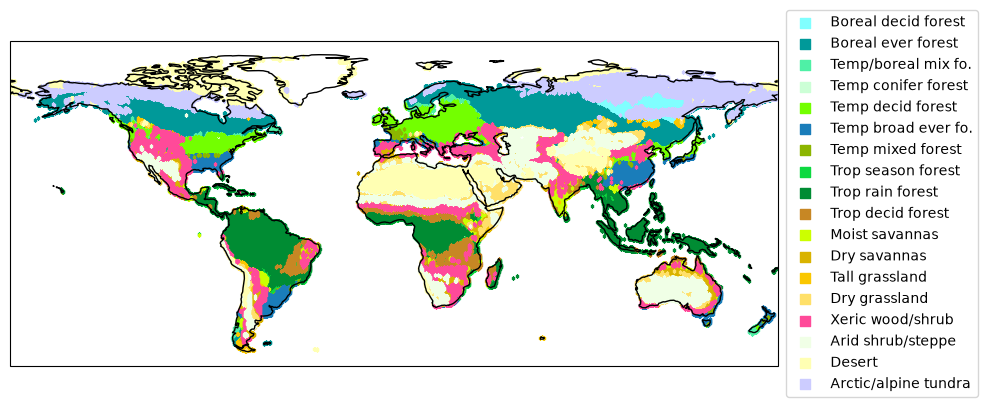

In [7]:
fig, ax = plt.subplots(figsize=(10, 5), subplot_kw=dict(projection=proj))

# Hacky way of creating a map, pretent it is a scatterplot with lons and lats on x and y!
for i, name in enumerate(biome_names):
    biome = biome_data[biome_data['Biome_obs'] == i +1]
    biome.plot(x='Lon', y='Lat', color=biome_rgbs[i], ax=ax, kind='scatter', s=.6, label=name, marker='s')


ax.legend(markerscale=10, loc='center right', bbox_to_anchor=(1.27, .5)) # Make markers bigger
ax.coastlines()
plt.tight_layout()
plt.show()

# Start your data formatting below. Good luck!

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import cross_val_score, train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report
from ISLP import load_data
import shap
import seaborn as sns

Data Visualization

Variables' distribution in EU 

In [31]:

df_pre   = pd.read_csv('data/Predaymean1961_1990_stats.csv')
df_tmp   = pd.read_csv('data/Tmpdaymean1961_1990_stats.csv')
df_tmax  = pd.read_csv('data/Tmaxdaymean1961_1990_stats.csv')
df_tmin  = pd.read_csv('data/Tmindaymean1961_1990_stats.csv')
df_tswrf = pd.read_csv('data/Tswrfdaymean1961_1990_stats.csv')

# 2. 定义函数：统一经纬度列名，并给其他特征列加前缀
def prepare_df(df, prefix):
    # 统一经纬度列名
    df = df.rename(columns={'lon': 'Lon', 'lat': 'Lat', 'longitude': 'Lon', 'latitude': 'Lat'})
    # 给除了 Lon, Lat 以外的所有列加上前缀（如 pre_SpringMean）
    rename_dict = {col: f"{prefix}_{col}" for col in df.columns if col not in ['Lon', 'Lat']}
    return df.rename(columns=rename_dict)

# 给各个表加上各自的前缀
df_pre   = prepare_df(df_pre, 'pre')
df_tmp   = prepare_df(df_tmp, 'tmp')
df_tmax  = prepare_df(df_tmax, 'tmax')
df_tmin  = prepare_df(df_tmin, 'tmin')
df_tswrf = prepare_df(df_tswrf, 'tswrf')

# 3. 拼合 5 个气候统计表（此时列名已各不相同，不会再冲突）
climate_dfs = [df_pre, df_tmp, df_tmax, df_tmin, df_tswrf]
df_climate = climate_dfs[0]
for df in climate_dfs[1:]:
    df_climate = pd.merge(df_climate, df, on=['Lon', 'Lat'], how='inner')

# 4. 读取目标表与 gridlist 辅助表
df_target = pd.read_csv('data/LPJ-GUESS_output_BERN1.csv')
gridlist  = pd.read_csv('gridlist_pan_gfed_ISO3_UN_ecoregion.txt', sep=r'\s+')

# 统一目标表和 gridlist 的经纬度列名
for df in [df_target, gridlist]:
    df.rename(columns={'lon': 'Lon', 'lat': 'Lat', 'longitude': 'Lon', 'latitude': 'Lat'}, inplace=True)

# 5. 三表最终大合并
df_merged = pd.merge(df_climate, df_target, on=['Lon', 'Lat'], how='inner')
df_merged = pd.merge(df_merged, gridlist, on=['Lon', 'Lat'], how='inner')

to_delete= ['pre_SpringMedian', 'pre_SpringStd','pre_SummerMedian', 'pre_SummerStd', 'pre_FallMedian', 'pre_FallStd', 'pre_WinterMedian', 'pre_WinterStd','tmp_SpringMedian', 'tmp_SpringStd','tmp_SummerMedian', 'tmp_SummerStd', 'tmp_FallMedian', 'tmp_FallStd', 'tmp_WinterMedian', 'tmp_WinterStd', 'tmax_SpringMedian', 'tmax_SpringStd', 'tmax_SummerMedian', 'tmax_SummerStd', 'tmax_FallMedian', 'tmax_FallStd', 'tmax_WinterMedian', 'tmax_WinterStd', 'tmin_SpringMedian', 'tmin_SpringStd', 'tmin_SummerMedian', 'tmin_SummerStd', 'tmin_FallMedian', 'tmin_FallStd', 'tmin_WinterMedian', 'tmin_WinterStd', 'tswrf_SpringMedian', 'tswrf_SpringStd', 'tswrf_SummerMedian', 'tswrf_SummerStd', 'tswrf_FallMedian', 'tswrf_FallStd', 'tswrf_WinterMedian', 'tswrf_WinterStd']
df_merged = df_merged.drop(columns=to_delete)
# ---------------------------------------------------------
# 6. 按 ISO3 切分四大洲
# ---------------------------------------------------------
df_canada = df_merged[df_merged['ISO3'] == 'CAN']
df_australia = df_merged[df_merged['ISO3'] == 'AUS']

europe_iso = [
    'SWE', 'NOR', 'FIN', 'DNK', 'ISL', 'GBR', 'IRL', 'DEU', 'FRA', 'ESP', 
    'PRT', 'ITA', 'NLD', 'BEL', 'CHE', 'AUT', 'POL', 'CZE', 'SVK', 'HUN', 
    'ROU', 'BGR', 'GRC', 'EST', 'LVA', 'LTU', 'BLR', 'UKR', 'HRV', 'SRB'
]
df_europe = df_merged[df_merged['ISO3'].isin(europe_iso)]

south_america_iso = [
    'BRA', 'ARG', 'COL', 'PER', 'VEN', 'CHL', 
    'ECU', 'BOL', 'PRY', 'URY', 'GUY', 'SUR'
]
df_south_america = df_merged[df_merged['ISO3'].isin(south_america_iso)]

# 打印各个区域的网格数量
print(f"Europe grid count: {len(df_europe)}")
print(f"Canada grid count: {len(df_canada)}")
print(f"South America grid count: {len(df_south_america)}")
print(f"Australia grid count: {len(df_australia)}")

Europe grid count: 3151
Canada grid count: 6499
South America grid count: 6190
Australia grid count: 2826


In [32]:
df_europe.head()

,Lon,Lat,pre_SpringMean,pre_SummerMean,pre_FallMean,pre_WinterMean,tmp_SpringMean,tmp_SummerMean,tmp_FallMean,tmp_WinterMean,...,LitterC,SoilC,Biome_Cmax,Biome_LAI,Biome_obs,GFED-region,Pan_2007,ISO3,UN,Ecoregion
12,24.25,51.75,0.98248,1.8373,2.0895,1.3034,270.75,285.99,289.39,276.10,...,9.439,16.046,5,5,5,11,Europe,BLR,112,4
33,25.75,50.75,0.98353,1.9468,2.1311,1.2233,270.59,286.20,289.55,275.97,...,6.723,15.222,5,5,5,11,Europe,UKR,804,4
45,10.25,62.25,1.04720,1.3020,2.3092,1.4383,264.44,276.09,280.66,268.64,...,18.294,28.623,2,2,2,6,N_Europe,NOR,578,11
50,28.25,64.25,1.11170,1.5451,2.4035,1.6442,262.43,279.57,285.03,269.05,...,18.268,31.691,2,2,2,6,N_Europe,FIN,246,6
73,19.75,68.75,1.11800,1.1252,1.9308,1.3779,261.56,274.35,280.43,266.17,...,0.803,14.560,11,11,18,6,N_Europe,NOR,578,11


In [34]:
print(df_europe.columns.tolist())

['Lon', 'Lat', 'pre_SpringMean', 'pre_SummerMean', 'pre_FallMean', 'pre_WinterMean', 'tmp_SpringMean', 'tmp_SummerMean', 'tmp_FallMean', 'tmp_WinterMean', 'tmax_SpringMean', 'tmax_SummerMean', 'tmax_FallMean', 'tmax_WinterMean', 'tmin_SpringMean', 'tmin_SummerMean', 'tmin_FallMean', 'tmin_WinterMean', 'tswrf_SpringMean', 'tswrf_SummerMean', 'tswrf_FallMean', 'tswrf_WinterMean', 'NPP', 'SoilR', 'MaxBiomeCmax', 'MaxBiomeLAI', 'VegC', 'LitterC', 'SoilC', 'Biome_Cmax', 'Biome_LAI', 'Biome_obs', 'GFED-region', 'Pan_2007', 'ISO3', 'UN', 'Ecoregion']


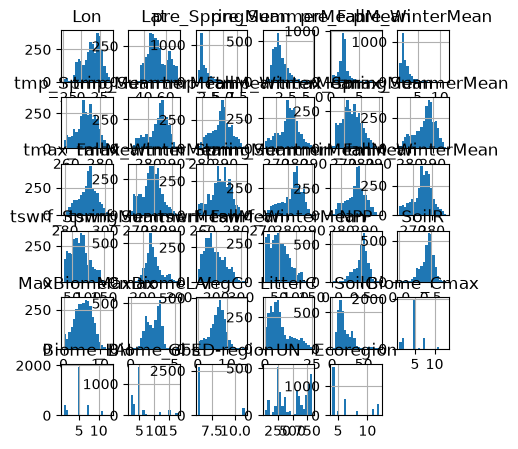

In [33]:
df_europe.hist(figsize=(5, 5), bins=20)
plt.show()

In [35]:
NUMERIC_COLUMNS = ['Lon', 'Lat', 'pre_SpringMean', 'pre_SummerMean', 'pre_FallMean', 'pre_WinterMean', 'tmp_SpringMean', 'tmp_SummerMean', 'tmp_FallMean', 'tmp_WinterMean', 'tmax_SpringMean', 'tmax_SummerMean', 'tmax_FallMean', 'tmax_WinterMean', 'tmin_SpringMean', 'tmin_SummerMean', 'tmin_FallMean', 'tmin_WinterMean', 'tswrf_SpringMean', 'tswrf_SummerMean', 'tswrf_FallMean', 'tswrf_WinterMean', 'NPP', 'SoilR', 'MaxBiomeCmax', 'MaxBiomeLAI', 'VegC', 'LitterC', 'SoilC', 'Biome_Cmax', 'Biome_LAI', 'Biome_obs', 'GFED-region', 'Pan_2007', 'ISO3', 'UN', 'Ecoregion']
correlation_matrix = df_europe[NUMERIC_COLUMNS].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)

plt.title('Correlation Matrix Heatmap')
plt.show()

ValueError: could not convert string to float: 'Europe'